# Part 9 — Cross-Area Representational Hierarchy

Tests whether the transient cross-mouse consistency observed in primary
visual cortex (VISp) propagates to or is amplified in downstream extrastriate
areas. Four higher visual areas (VISl, VISal, VISpm, VISam) are analysed with
the same RSA pipeline used for VISp throughout Parts 1–7.

Two complementary displays are provided:
(A) Bar chart of raw peak consistency (Spearman r) per area, collapsing
    time. Per-area within-mouse response reliability is reported separately
    as context (all areas ~0.96-0.98, near-ceiling and broadly comparable)
    rather than used to normalise consistency, since a properly RDM-scoped
    ceiling isn't computable for the non-VISp areas with the cached data
    (see Part 1 Sec 1.3b).
(B) Temporal curves for all five areas side by side — this shows whether the
    transient structure of VISp is preserved, amplified, or flattened
    in higher areas.

Non-VISp within-mouse reliability values are precomputed in the preprocessing
notebook and stored inside `responses.h5` (see `ARCHIVE_CONTENTS.md` §3)
because their computation requires single-trial spike data not cached
elsewhere.

**Depends on:** `responses.h5` (all five areas: natural-scenes tensors and
               non-VISp reliability values), `part1_outputs.npz` (VISp
               reliability and consistency), `part3_outputs.npz` (VISp
               temporal profile), `manifest.json`
**Outputs saved:** none (terminal notebook)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

SEED = 42

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors      = apply_plot_style()
COL_FIT     = colors["COL_FIT"]           # peak annotations
COL_REF     = colors["COL_REF"]           # reference lines / baselines
AREA_COLORS = colors["AREA_COLORS"]       # five-area palette (VISp == COL_DATA blue)
AREAS       = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam']

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES         = manifest['n_images']
AREA_SESSION_IDS = manifest['area_session_ids']
VISP_SESSION_IDS = manifest['selected_session_ids_visp']
AREAS            = ['VISp', 'VISl', 'VISal', 'VISpm', 'VISam']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
visp_nc_per_session = p1['noise_ceiling']           # (32, 118)
visp_mean_nc        = visp_nc_per_session.mean()    # scalar

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms_visp     = p3['times_ms']
mean_c_visp       = p3['mean_c']
window_centers_ms = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS   = float(p3['window_width_ms'])
peak_t_visp       = float(p3['peak_t'])
peak_c_visp       = float(p3['peak_c'])

SLIDE_START_MS = int(times_ms_visp.min())
SLIDE_END_MS   = int(times_ms_visp.max()) + 1

print(f'VISp: {len(VISP_SESSION_IDS)} sessions, '
      f'mean NC = {visp_mean_nc:.4f}, peak = {peak_c_visp:.4f}')
for area in AREAS[1:]:
    print(f'{area}: {len(AREA_SESSION_IDS.get(area, []))} sessions')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
VISp: 32 sessions, mean NC = 0.9778, peak = 0.3065
VISl: 24 sessions
VISal: 23 sessions
VISpm: 20 sessions
VISam: 26 sessions


## 9.1 — Load area tensors and noise ceilings from the archive

Area tensors are loaded one area at a time to avoid holding all five areas in
memory simultaneously. Non-VISp noise ceilings are read directly from
`responses.h5` (precomputed during preprocessing; see `PREPROCESSING_STRATEGIES.md`
§4 for rationale). The VISp noise ceiling is taken from Part 1's output array.

In [3]:
area_noise_ceilings = {'VISp': visp_mean_nc}

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        nc = f[f'natural_scenes/{area}/noise_ceiling'][:]  # (n_sessions, 118)
        area_noise_ceilings[area] = nc.mean()
        print(f'{area}: mean NC = {nc.mean():.4f}  '
              f'(n_sessions = {nc.shape[0]})')

print(f'\nNoise ceilings by area:')
for area in AREAS:
    print(f'  {area}: {area_noise_ceilings[area]:.4f}')

VISl: mean NC = 0.9644  (n_sessions = 24)
VISal: mean NC = 0.9743  (n_sessions = 23)
VISpm: mean NC = 0.9737  (n_sessions = 20)
VISam: mean NC = 0.9753  (n_sessions = 26)

Noise ceilings by area:
  VISp: 0.9778
  VISl: 0.9644
  VISal: 0.9743
  VISpm: 0.9737
  VISam: 0.9753


## 9.2 — Fixed-window (0–250 ms) consistency per area

For each area, the 32-session (or area-specific n-session) RSA pipeline is
applied to the 0–250 ms response matrix, giving raw per-image mean
consistency. Within-mouse response reliability is also reported per area as
context (all areas are near-ceiling and broadly comparable, ~0.96–0.98), but
consistency is reported as a raw Spearman r, not normalised by it.

In [4]:
T_LO_FIXED, T_HI_FIXED = 0, 250

area_consistency_fixed = {}   # area → scalar mean consistency

# VISp: use Part 3's sliding-window data averaged over 0–250 ms window
visp_fixed_mask = (times_ms_visp >= T_LO_FIXED) & (times_ms_visp <= T_HI_FIXED)
area_consistency_fixed['VISp'] = mean_c_visp[visp_fixed_mask].mean()

# Non-VISp areas: compute directly from their binned tensors
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        sids = AREA_SESSION_IDS.get(area, [])
        if not sids:
            area_consistency_fixed[area] = np.nan
            continue
        mats = []
        for sid in sids:
            tensor = f[f'natural_scenes/{area}/{sid}/tensor'][:]
            X      = window_response(tensor, T_LO_FIXED, T_HI_FIXED)
            mats.append(X)
            del tensor
        sims      = compute_similarity_matrices(mats)
        c, _, _   = per_image_consistency(sims)
        area_consistency_fixed[area] = c.mean()
        gc.collect()

print('\nFixed-window (0–250 ms) mean consistency by area:')
for area in AREAS:
    c   = area_consistency_fixed[area]
    nc  = area_noise_ceilings[area]
    print(f'  {area}: r = {c:.4f}  (within-mouse reliability = {nc:.4f})')


Fixed-window (0–250 ms) mean consistency by area:
  VISp: r = 0.1830  (within-mouse reliability = 0.9778)
  VISl: r = 0.2022  (within-mouse reliability = 0.9644)
  VISal: r = 0.2485  (within-mouse reliability = 0.9743)
  VISpm: r = 0.2441  (within-mouse reliability = 0.9737)
  VISam: r = 0.2608  (within-mouse reliability = 0.9753)


## 9.3 — Sliding-window temporal profiles for all five areas

The 25 ms / 10 ms-step sliding window from Part 3 is applied to each area.
Each area's curve uses the sessions available for that area
(24–32 sessions depending on area; see `manifest['area_session_ids']`).
Loading and discarding tensors per area avoids peak memory scaling with the
number of areas.

In [5]:
area_sliding_curves = {'VISp': (times_ms_visp, mean_c_visp)}

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for area in AREAS[1:]:
        sids = AREA_SESSION_IDS.get(area, [])
        if not sids:
            area_sliding_curves[area] = (np.array([]), np.array([]))
            continue

        # Load all sessions for this area into memory
        tensors_area = {}
        for sid in sids:
            tensors_area[sid] = f[f'natural_scenes/{area}/{sid}/tensor'][:]

        sliding = {}
        for t_ms in window_centers_ms:
            t_lo = t_ms - WINDOW_WIDTH_MS / 2
            t_hi = t_ms + WINDOW_WIDTH_MS / 2
            mats = [window_response(tensors_area[sid], t_lo, t_hi)
                    for sid in sids]
            sims = compute_similarity_matrices(mats)
            c, _, _ = per_image_consistency(sims)
            sliding[t_ms] = c.mean()

        t_arr = np.array(sorted(sliding))
        c_arr = np.array([sliding[t] for t in t_arr])
        area_sliding_curves[area] = (t_arr, c_arr)

        peak_area = c_arr[(t_arr >= 0) & (t_arr <= 250)].max()
        peak_t_area = t_arr[(t_arr >= 0) & (t_arr <= 250)][
            np.argmax(c_arr[(t_arr >= 0) & (t_arr <= 250)])
        ]
        print(f'{area}: peak = {peak_area:.4f} at {peak_t_area:.0f} ms')

        del tensors_area, sliding
        gc.collect()

VISl: peak = 0.1857 at 110 ms


VISal: peak = 0.2341 at 100 ms


VISpm: peak = 0.2097 at 120 ms


VISam: peak = 0.2380 at 110 ms


## 9.4 — Peak and T/S ratios by area

Report each area's raw sliding-window peak consistency (Spearman r).
Compute T/S ratio as peak consistency / sustained (220–250 ms) consistency,
identical to the convention used in Parts 3 and 5.

In [6]:
area_stats = {}

for area in AREAS:
    t_arr, c_arr = area_sliding_curves[area]
    if len(c_arr) == 0:
        area_stats[area] = dict(peak=np.nan, peak_t=np.nan, sust=np.nan, ts=np.nan)
        continue

    post_mask  = (t_arr >= 0) & (t_arr <= 250)
    sust_mask  = (t_arr >= 220) & (t_arr <= 250)
    peak_c_a   = c_arr[post_mask].max()
    peak_t_a   = t_arr[post_mask][np.argmax(c_arr[post_mask])]
    sust_a     = c_arr[sust_mask].mean() if sust_mask.any() else 0.0
    ts_a       = peak_c_a / (sust_a + 1e-8)

    area_stats[area] = dict(peak=peak_c_a, peak_t=peak_t_a, sust=sust_a, ts=ts_a)

print('\nArea summary statistics:')
print(f'{"Area":<6}  {"Peak r":>7}  {"Peak t(ms)":>10}  '
      f'{"Sust r":>7}  {"T/S":>5}')
print('-' * 45)
for area in AREAS:
    s = area_stats[area]
    print(f'{area:<6}  {s["peak"]:>7.4f}  {s["peak_t"]:>10.0f}  '
          f'{s["sust"]:>7.4f}  {s["ts"]:>5.2f}')


Area summary statistics:
Area     Peak r  Peak t(ms)   Sust r    T/S
---------------------------------------------
VISp     0.3065         100   0.1821   1.68
VISl     0.1857         110   0.0914   2.03
VISal    0.2341         100   0.1270   1.84
VISpm    0.2097         120   0.1203   1.74
VISam    0.2380         110   0.1187   2.00


---
## Figures

**Fig. 9** — Cross-mouse representational consistency is highest in V1 and
lower and roughly comparable across four extrastriate areas.


Fig 9B — Peak consistency and T/S ratio by area

--- area_labels ---
['VISp', 'VISl', 'VISal', 'VISpm', 'VISam']

--- peak_consistency ---
[0.30653  0.185684 0.234081 0.209675 0.23801 ]

--- transient_to_sustained_ratio ---
[1.683269 2.030738 1.843879 1.74263  2.004717]

--- within_mouse_reliability ---
[0.977762 0.964386 0.974333 0.973723 0.975291]

Fig 9A — Temporal profiles of cross-mouse consistency across five visual areas

--- area_labels ---
['VISp', 'VISl', 'VISal', 'VISpm', 'VISam']

--- VISp_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- VISl_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- VISal_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- VISpm_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50 

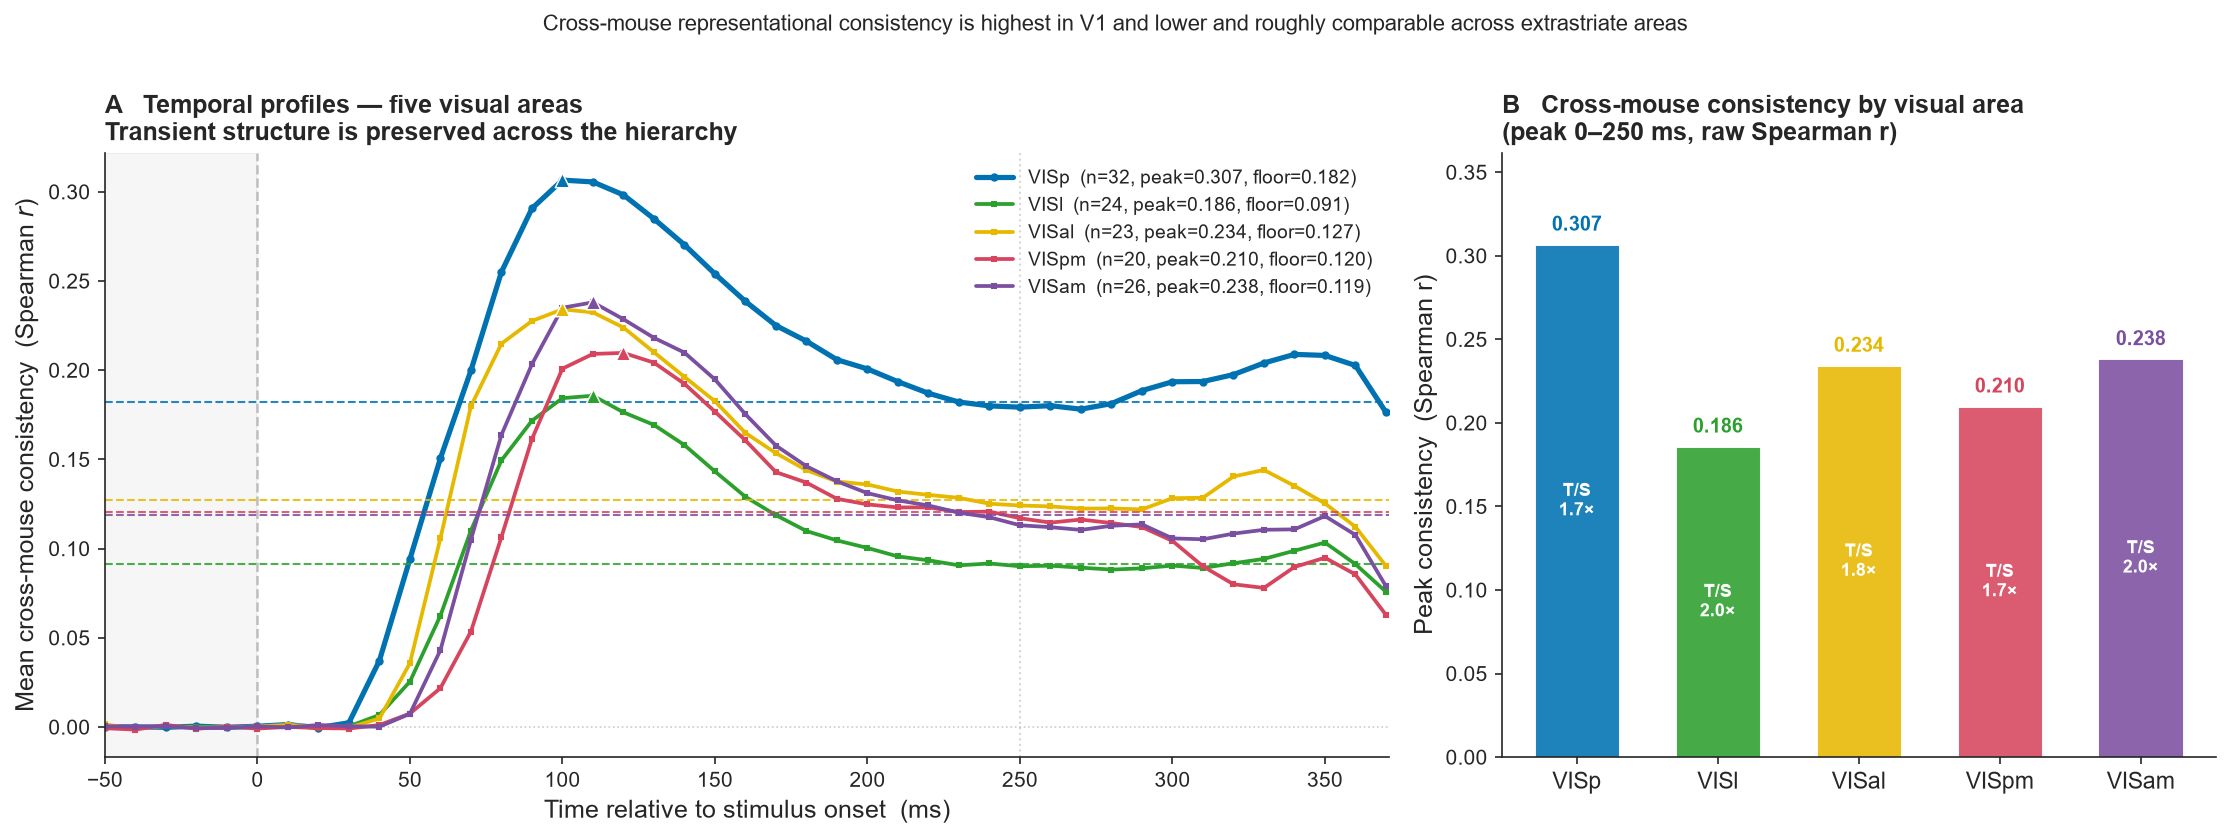

In [7]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5.5),
    gridspec_kw={'width_ratios': [1.8, 1]}
)

text_bbox = dict(facecolor='white', alpha=0.7, edgecolor='none')

def mark_peak_floor(ax, t, c, peak, sus, color, y_offset=None,
                    sustained_lo=220, sustained_hi=250):
    t = np.asarray(t)
    c = np.asarray(c)
    post_mask = (t >= 0) & (t <= 250)
    if np.any(post_mask):
        peak_t = t[post_mask][np.argmax(c[post_mask])]
    else:
        peak_t = t[np.argmax(c)]

    ax.scatter([peak_t], [peak], marker='^', s=48, color=color, zorder=6,
               edgecolor='white', linewidth=0.7)

    ax.hlines(sus, SLIDE_START_MS, SLIDE_END_MS,
              colors=color, linewidth=1.0, linestyle='--', alpha=0.85)
    if y_offset is None:
        y_offset = max(0.01, abs(peak) * 0.04)

# ── Panel B: raw peak consistency by area (bar chart) ─────────────────────────
ax = axes[1]
peak_vals = [area_stats[a]['peak'] for a in AREAS]
ts_vals   = [area_stats[a]['ts']   for a in AREAS]
bar_cols  = [AREA_COLORS[a] for a in AREAS]
x         = np.arange(len(AREAS))

bars = ax.bar(x, peak_vals, color=bar_cols, alpha=0.88, width=0.6,
              edgecolor='white', linewidth=0.5)

# Label bars: peak r value + T/S ratio
for i, (bar, pk, ts_v) in enumerate(zip(bars, peak_vals, ts_vals)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f'{pk:.3f}', ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color=bar_cols[i])
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'T/S\n{ts_v:.1f}×', ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(AREAS, fontsize=11)
ax.set_ylabel('Peak consistency  (Spearman r)')
ax.set_title('B   Cross-mouse consistency by visual area\n'
             '(peak 0–250 ms, raw Spearman r)',
             loc='left', fontweight='bold', pad=6)
ax.set_ylim(0, max(peak_vals) * 1.18)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel A: temporal curves for all five areas ───────────────────────────────
ax = axes[0]
ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.0, alpha=0.4)
ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)

for area in AREAS:
    t_arr, c_arr = area_sliding_curves[area]
    if len(c_arr) == 0:
        continue
    n_sessions = len(AREA_SESSION_IDS.get(area, VISP_SESSION_IDS))
    lw    = 2.5 if area == 'VISp' else 1.8
    ls    = '-'
    mkr   = 'o' if area == 'VISp' else 's'
    mksz  = 3.0 if area == 'VISp' else 2.0
    ax.plot(t_arr, c_arr, color=AREA_COLORS[area], linewidth=lw,
            linestyle=ls, marker=mkr, markersize=mksz,
            label=f'{area}  (n={n_sessions}, peak={area_stats[area]["peak"]:.3f}, floor={area_stats[area]["sust"]:.3f})')
    mark_peak_floor(ax, t_arr, c_arr,
                    area_stats[area]['peak'], area_stats[area]['sust'],
                    AREA_COLORS[area])

ax.set_xlabel('Time relative to stimulus onset  (ms)')
ax.set_ylabel('Mean cross-mouse consistency  (Spearman $r$)')
ax.set_title('A   Temporal profiles — five visual areas\n'
             'Transient structure is preserved across the hierarchy',
             loc='left', fontweight='bold', pad=6)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Cross-mouse representational consistency is highest in V1 and '
             'lower and roughly comparable across extrastriate areas',
             fontsize=10.5, y=1.01)

print_figure_data(
    'Fig 9B — Peak consistency and T/S ratio by area',
    area_labels=AREAS,
    peak_consistency=np.array(peak_vals),
    transient_to_sustained_ratio=np.array(ts_vals),
    within_mouse_reliability=np.array([area_noise_ceilings[a] for a in AREAS]),
)
print_figure_data(
    'Fig 9A — Temporal profiles of cross-mouse consistency across five visual areas',
    area_labels=AREAS,
    **{f'{area}_times_ms': area_sliding_curves[area][0] for area in AREAS},
    **{f'{area}_mean_consistency': area_sliding_curves[area][1] for area in AREAS},
    peak_consistency_per_area=np.array([area_stats[a]['peak'] for a in AREAS]),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_cross_area_hierarchy.png', bbox_inches='tight')
plt.show()